# Baseline: Random Forest with HOG Features
### 204466 Deep Learning — Final Project
**Purpose:** Traditional ML baseline to compare with Custom CNN  
**Method:** Extract HOG (Histogram of Oriented Gradients) features → Random Forest classifier

## 1. Setup & Mount Google Drive

In [32]:
!pip install kaggle scikit-image -q

from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/skin_lesion/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory: /content/drive/MyDrive/skin_lesion/


## 2. Download Dataset

In [33]:
os.environ["KAGGLE_USERNAME"] = "thanutham"
os.environ["KAGGLE_KEY"] = "KGAT_b1350be88c0d761b73bdb8b5750fc6ad"

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000

import zipfile
with zipfile.ZipFile('/content/ham10000/skin-cancer-mnist-ham10000.zip', 'r') as z:
    z.extractall('/content/ham10000')

print('Dataset ready!')

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
skin-cancer-mnist-ham10000.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset ready!


## 3. Import Libraries

In [34]:
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

print('Libraries loaded')

Libraries loaded


## 4. Load Dataset

In [35]:
label_map = {
    'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3,
    'akiec': 4, 'vasc': 5, 'df': 6
}
class_names = list(label_map.keys())

metadata = pd.read_csv('/content/ham10000/HAM10000_metadata.csv')
metadata['label'] = metadata['dx'].map(label_map)

image_paths = {}
for folder in ['/content/ham10000/HAM10000_images_part_1',
               '/content/ham10000/HAM10000_images_part_2']:
    for img_path in glob.glob(os.path.join(folder, '*.jpg')):
        img_id = os.path.splitext(os.path.basename(img_path))[0]
        image_paths[img_id] = img_path

metadata['path'] = metadata['image_id'].map(image_paths)
metadata = metadata.dropna(subset=['path'])

train_df, temp_df = train_test_split(metadata, test_size=0.30, stratify=metadata['label'], random_state=42)
val_df,   test_df = train_test_split(temp_df,  test_size=0.50, stratify=temp_df['label'],  random_state=42)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 7010 | Val: 1502 | Test: 1503


## 5. Extract HOG Features
HOG captures edge and gradient structure — commonly used in traditional CV pipelines.  
Each image is resized to **64×64** and converted to a feature vector.

In [36]:
def extract_hog_features(df, img_size=64):
    features, labels = [], []
    for _, row in df.iterrows():
        img  = np.array(Image.open(row['path']).convert('RGB').resize((img_size, img_size)))
        feat = hog(img, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), channel_axis=-1)
        features.append(feat)
        labels.append(int(row['label']))
    return np.array(features), np.array(labels)

print('Extracting HOG features from train set...')
X_train, y_train = extract_hog_features(train_df)
print(f'Train shape: {X_train.shape}')

print('Extracting HOG features from test set...')
X_test, y_test = extract_hog_features(test_df)
print(f'Test shape : {X_test.shape}')

Extracting HOG features from train set...
Train shape: (7010, 1764)
Extracting HOG features from test set...
Test shape : (1503, 1764)


## 6. Train Random Forest

In [37]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Training Random Forest...')
rf.fit(X_train, y_train)
print('Training complete!')

Training Random Forest...
Training complete!


## 7. Evaluation

In [38]:
y_pred = rf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n')
print(classification_report(y_test, y_pred, target_names=class_names))

Test Accuracy: 0.6693 (66.93%)

              precision    recall  f1-score   support

          nv       0.67      1.00      0.80      1006
         mel       0.00      0.00      0.00       167
         bkl       0.00      0.00      0.00       165
         bcc       0.00      0.00      0.00        77
       akiec       0.00      0.00      0.00        49
        vasc       0.00      0.00      0.00        22
          df       0.00      0.00      0.00        17

    accuracy                           0.67      1503
   macro avg       0.10      0.14      0.11      1503
weighted avg       0.45      0.67      0.54      1503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


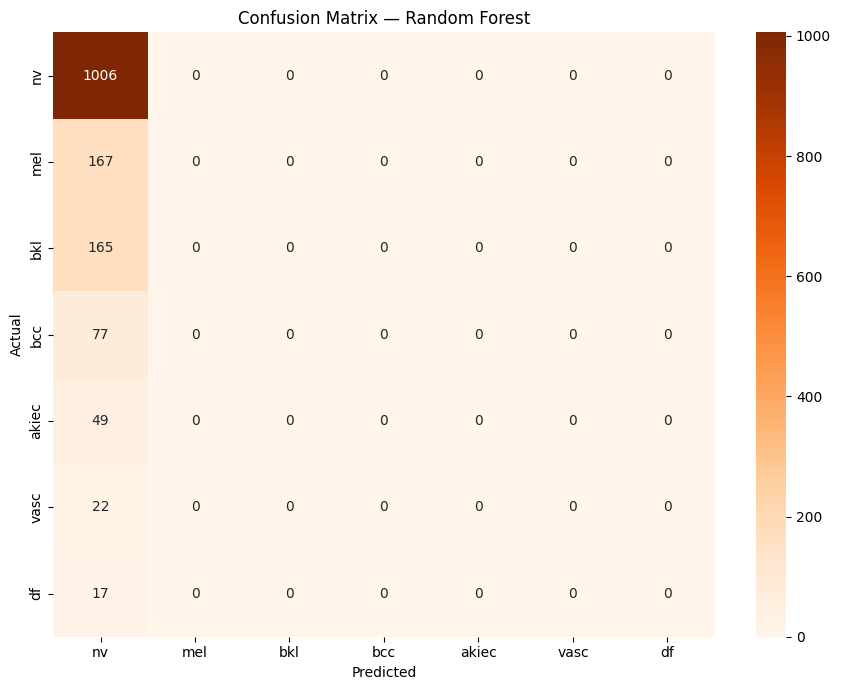

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'rf_confusion_matrix.png', dpi=150)
plt.show()

## 8. Save Results for Comparison

In [40]:
results = {
    'model'    : 'Random Forest (HOG features)',
    'accuracy' : float(acc),
    'precision': float(precision_score(y_test, y_pred, average='weighted', zero_division=0)),
    'recall'   : float(recall_score(y_test,    y_pred, average='weighted', zero_division=0)),
    'f1'       : float(f1_score(y_test,         y_pred, average='weighted', zero_division=0)),
    'per_class_f1': {
        class_names[i]: float(f)
        for i, f in enumerate(f1_score(y_test, y_pred, average=None, zero_division=0))
    }
}

with open(SAVE_DIR + 'rf_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'Results saved to {SAVE_DIR}rf_results.json')
print(f'  Accuracy : {results["accuracy"]:.4f}')
print(f'  Precision: {results["precision"]:.4f}')
print(f'  Recall   : {results["recall"]:.4f}')
print(f'  F1       : {results["f1"]:.4f}')

Results saved to /content/drive/MyDrive/skin_lesion/rf_results.json
  Accuracy : 0.6693
  Precision: 0.4480
  Recall   : 0.6693
  F1       : 0.5367
